# Natural Language Inference for Historical Text Analysis

This notebook implements the full NLP pipeline for analyzing nineteenth-century British Columbia court rulings on Chinese immigration using text embeddings, zero-shot NLI classification, and robustness checks.

## 1. Setup and Imports

In [ ]:
%pip install pandas numpy matplotlib seaborn scikit-learn scipy nltk tqdm spacy umap-learn torch transformers sentence-transformers

  Using cached transformers-5.5.4-py3-none-any.whl.metadata (32 kB)
  Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl.metadata (6.6 kB)


ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11; 1.26.0 Requires-Python >=3.9,<3.13; 1.26.1 Requires-Python >=3.9,<3.13
ERROR: Could not find a version that satisfies the requirement difflib (from versions: none)
ERROR: No matching distribution found for difflib


In [1]:
import pandas as pd
import numpy as np
import re
import os
import textwrap
import warnings
import difflib
from collections import defaultdict, Counter

import matplotlib.pyplot as plt
import seaborn as sns
import umap
import spacy
from nltk import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cosine
from scipy import stats
from sentence_transformers import SentenceTransformer
from transformers import pipeline, AutoTokenizer
import torch

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

nlp = spacy.load('en_core_web_sm')
warnings.filterwarnings('ignore')

# Ensure we're in the notebook's directory
NB_DIR = os.path.join(
    r'C:\Users\Kaiyan Zhang\Desktop\TLEF Project\share-ai',
    'project', 'docs', 'hist_workshop'
)
os.chdir(NB_DIR)
DATA_DIR = 'data'

print(f'Working directory: {os.getcwd()}')
print('Setup complete.')

c:\Users\Kaiyan Zhang\Desktop\TLEF Project\share-ai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Working directory: C:\Users\Kaiyan Zhang\Desktop\TLEF Project\share-ai\project\docs\hist_workshop
Setup complete.


## 2. Load the Corpus

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, 'metadata_cleaned.csv'))
df['doc_length'] = df['text'].apply(len)
df[['filename', 'author', 'type', 'doc_length',
    'act_quote_sentences_removed']]

,filename,author,type,doc_length,act_quote_sentences_removed
0,regina_v_wing_chong.txt,Crease,case,36819,12
1,wong_hoy_woon_v_duncan.txt,Crease,case,13912,0
2,regina_v_mee_wah.txt,Begbie,case,25104,0
3,regina_v_victoria.txt,Begbie,case,8252,0
4,quong_wing_v_the_king.txt,Fitzpatrick,case,46982,0
5,commission_on_chinese_imigration.txt,Powell,report,3402,0
6,chapleau_report_resume.txt,Chapleau,report,10906,0
7,crease_commission.txt,Crease,report,30768,0
8,begbie_commission.txt,Begbie,report,41270,0
9,chinese_regulation_act_1884.txt,Others,act,12908,0


## 3. Fuzzy Quote Detection

Rather than binary deletion of quoted text, we use fuzzy string matching to **tag** sentences with their similarity to the Act. This lets us run a sensitivity analysis: results with and without high-similarity sentences.

In [3]:
# Load the Act text for comparison
act_text = df.loc[
    df['type'] == 'act', 'text'
].values[0]
act_sents = [s.text.strip() for s in nlp(act_text).sents
             if len(s.text.strip()) > 20]
print(f'Act sentences: {len(act_sents)}')

# Load Crease's full (unmodified) case text
with open(os.path.join(
    DATA_DIR, 'Regina_V_Wing_Chong.txt'
), encoding='utf-8') as f:
    crease_orig = f.read()

crease_sents = [
    s.text.strip()
    for s in nlp(crease_orig).sents
    if len(s.text.strip()) > 20
]
print(f'Crease sentences (original): {len(crease_sents)}')

Act sentences: 41
Crease sentences (original): 218


In [4]:
def compute_quote_similarity(sent, reference_sents):
    """Compute max similarity of sent against
    all reference sentences using SequenceMatcher."""
    best = 0.0
    s_lower = sent.lower()
    for ref in reference_sents:
        ratio = difflib.SequenceMatcher(
            None, s_lower, ref.lower()
        ).ratio()
        if ratio > best:
            best = ratio
    return best

# Tag each Crease sentence with quote similarity
crease_quote_scores = []
for sent in crease_sents:
    score = compute_quote_similarity(sent, act_sents)
    crease_quote_scores.append({
        'sentence': sent,
        'quote_similarity': score,
    })

quote_df = pd.DataFrame(crease_quote_scores)
print(f'Sentences above 0.6 similarity: '
      f'{(quote_df["quote_similarity"] > 0.6).sum()}')
print(f'Sentences above 0.4 similarity: '
      f'{(quote_df["quote_similarity"] > 0.4).sum()}')

# Show some high-similarity sentences
print('\nHigh-similarity sentences (likely quotes):')
top_quotes = quote_df.nlargest(5, 'quote_similarity')
for _, row in top_quotes.iterrows():
    print(f'  [{row["quote_similarity"]:.3f}] '
          f'{row["sentence"][:80]}...')

Sentences above 0.6 similarity: 12
Sentences above 0.4 similarity: 30

High-similarity sentences (likely quotes):
  [0.991] “In case any employer of Chinese fails to deliver to the “collector the list men...
  [0.987] "Any collector or Government servant wilfully disobeying "any of the provisions ...
  [0.985] “Every employer of Chinese shall furnish to the collector “when requested by him...
  [0.970] Proof of the lawful possession of “such receipt shall lie on the person whose go...
  [0.926] "Every collector shall collect the tax from each Chinese, "and shall as soon aft...


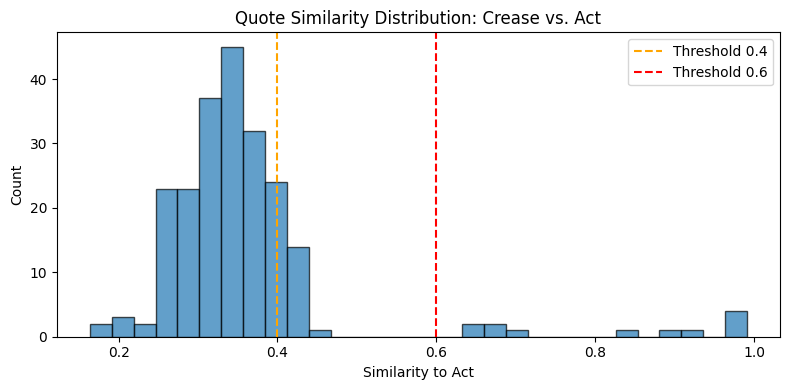

In [5]:
# Visualize quote similarity distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    quote_df['quote_similarity'],
    bins=30, edgecolor='black', alpha=0.7,
)
ax.axvline(
    x=0.4, color='orange',
    linestyle='--', label='Threshold 0.4',
)
ax.axvline(
    x=0.6, color='red',
    linestyle='--', label='Threshold 0.6',
)
ax.set_xlabel('Similarity to Act')
ax.set_ylabel('Count')
ax.set_title(
    'Quote Similarity Distribution: '
    'Crease vs. Act'
)
ax.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(DATA_DIR, 'quote_similarity_dist.png'),
    dpi=150,
)
plt.show()

## 4. Exploratory Analysis: TF-IDF

In [6]:
stop_words = set(stopwords.words('english'))
stop_words.update(
    {'would', 'may', 'act', 'mr',
     'sir', 'also', 'upon', 'shall'}
)

def preprocess_text(text_string):
    text = text_string.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    filtered = [
        w for w in tokens
        if w not in stop_words and len(w) > 4
    ]
    return ' '.join(filtered)

df['processed_text'] = df['text'].apply(preprocess_text)

df['group'] = 'Other'
df.loc[df['author'] == 'Crease', 'group'] = 'Crease'
df.loc[df['author'] == 'Begbie', 'group'] = 'Begbie'
df.loc[
    df['author'] == 'Others', 'group'
] = 'Regulation Act'

vectorizer = TfidfVectorizer(
    max_features=1000, ngram_range=(1, 3)
)
tfidf_matrix = vectorizer.fit_transform(
    df['processed_text']
)
feature_names = vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names,
)
tfidf_df['group'] = df['group'].values
mean_tfidf = tfidf_df.groupby('group').mean()

for group in ['Crease', 'Begbie',
              'Regulation Act', 'Other']:
    top = (
        mean_tfidf.loc[group]
        .sort_values(ascending=False)
        .head(10)
    )
    print(f'\n--- {group} ---')
    print(top)


--- Crease ---
chinese           0.200669
labor             0.168787
infected          0.133485
white             0.126410
taxation          0.103702
british           0.096697
hongkong          0.095346
dominion          0.092157
health officer    0.088990
china             0.088562
Name: Crease, dtype: float64

--- Begbie ---
license         0.227903
chinamen        0.149081
licenses        0.133026
municipality    0.113649
statute         0.103615
legislature     0.098166
revenue         0.096980
corporation     0.093326
pawnbrokers     0.085237
provincial      0.084121
Name: Begbie, dtype: float64

--- Regulation Act ---
chinese                       0.441993
dollars                       0.282347
licence                       0.247053
collector                     0.211760
forfeit                       0.189818
lieutenantgovernor            0.189818
person                        0.189591
possession                    0.188270
exceeding                     0.176467
lieutenantgover

## 5. Model Selection

**Embedding model**: `sentence-transformers/all-mpnet-base-v2`
- 110M parameters, 768 dimensions
- Trained on 1 billion sentence pairs for sentence similarity (contrastive learning)
- Top performer on the [MTEB benchmark](https://huggingface.co/spaces/mteb/leaderboard) among base-sized models
- Unlike Legal-BERT (MLM-only, requires manual mean pooling), this model is specifically designed for producing sentence embeddings via pooling built into the architecture

**NLI model**: `MoritzLaurer/deberta-v3-large-zeroshot-v2.0`
- 0.4B parameters, MIT license
- Same author's updated model (v2.0 vs v1.0), trained on synthetic + human NLI data
- Benchmarked on 28 zero-shot tasks with clear improvements over the previous version and bart-large-mnli
- DeBERTa's disentangled attention captures word-position relationships useful for complex legal syntax

In [7]:
# Load embedding model
embed_model = SentenceTransformer(
    'sentence-transformers/all-mpnet-base-v2'
)
print('Embedding model loaded.')
print(f'Embedding dimension: '
      f'{embed_model.get_sentence_embedding_dimension()}')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3924.46it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model loaded.
Embedding dimension: 768


In [8]:
# Load NLI model
nli_model_name = (
    'MoritzLaurer/'
    'deberta-v3-large-zeroshot-v2.0'
)
zero_shot = pipeline(
    'zero-shot-classification',
    model=nli_model_name,
    device=0 if torch.cuda.is_available() else -1,
)
print('NLI model loaded.')

Loading weights: 100%|██████████| 394/394 [00:00<00:00, 4355.80it/s]


NLI model loaded.


## 6. Extract Author Snippets

In [9]:
crease_cases = df[
    (df['author'] == 'Crease')
    & (df['type'] == 'case')
]['text'].tolist()
begbie_cases = df[
    (df['author'] == 'Begbie')
    & (df['type'] == 'case')
]['text'].tolist()
act_1884 = df[
    df['type'] == 'act'
]['text'].tolist()

act_dict = {
    'Crease': crease_cases,
    'Begbie': begbie_cases,
    'Act 1884': act_1884,
}

keywords = [
    'Chinese', 'China', 'Chinaman',
    'Chinamen', 'immigrant', 'immigrants',
    'alien', 'aliens', 'immigration',
]

act_snippets = {}
for auth, texts in act_dict.items():
    snippets = []
    for txt in texts:
        sents = [s.text for s in nlp(txt).sents]
        for s in sents:
            if any(kw in s for kw in keywords):
                snippets.append(s)
    act_snippets[auth] = snippets

for auth, snips in act_snippets.items():
    print(f'{auth}: {len(snips)} snippets')

Crease: 83 snippets
Begbie: 18 snippets
Act 1884: 24 snippets


## 7. Generate Embeddings with all-mpnet-base-v2

Unlike Legal-BERT (which requires manual tokenization, forward pass, and mean pooling), `sentence-transformers` handles all of this internally with a single `encode()` call.

In [10]:
embeddings_dict = {}
for auth, snippets in act_snippets.items():
    if not snippets:
        embeddings_dict[auth] = []
        continue
    vecs = embed_model.encode(
        snippets, show_progress_bar=True,
        batch_size=32,
    )
    embeddings_dict[auth] = list(vecs)
    print(f'{auth}: {len(vecs)} embeddings, '
          f'shape {vecs.shape}')

# Save embeddings
np.savez(
    os.path.join(DATA_DIR, 'case_snippet_embeddings.npz'),
    **{k: np.array(v) for k, v in embeddings_dict.items()},
)
print('Embeddings saved to case_snippet_embeddings.npz')

Batches: 100%|██████████| 3/3 [00:07<00:00,  2.35s/it]


Crease: 83 embeddings, shape (83, 768)


Batches: 100%|██████████| 1/1 [00:02<00:00,  2.87s/it]


Begbie: 18 embeddings, shape (18, 768)


Batches: 100%|██████████| 1/1 [00:05<00:00,  5.47s/it]

Act 1884: 24 embeddings, shape (24, 768)
Embeddings saved to case_snippet_embeddings.npz


### Cosine Similarity Between Authors

In [11]:
mean_crease = np.mean(
    embeddings_dict['Crease'], axis=0, keepdims=True
)
mean_begbie = np.mean(
    embeddings_dict['Begbie'], axis=0, keepdims=True
)
mean_act = np.mean(
    embeddings_dict['Act 1884'], axis=0, keepdims=True
)

pairs = [
    ('Crease', 'Begbie', mean_crease, mean_begbie),
    ('Crease', 'Act 1884', mean_crease, mean_act),
    ('Begbie', 'Act 1884', mean_begbie, mean_act),
]
for a, b, va, vb in pairs:
    sim = cosine_similarity(va, vb)[0, 0]
    print(f'Cosine similarity ({a} vs {b}): {sim:.4f}')

Cosine similarity (Crease vs Begbie): 0.8301
Cosine similarity (Crease vs Act 1884): 0.8229
Cosine similarity (Begbie vs Act 1884): 0.8139


### UMAP Visualization

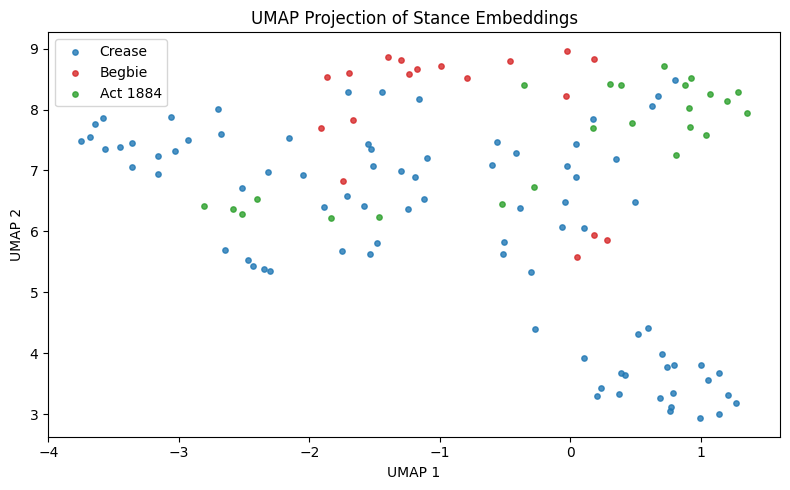

In [12]:
all_vecs = np.vstack(
    embeddings_dict['Crease']
    + embeddings_dict['Begbie']
    + embeddings_dict['Act 1884']
)
labels = (
    ['Crease'] * len(embeddings_dict['Crease'])
    + ['Begbie'] * len(embeddings_dict['Begbie'])
    + ['Act 1884'] * len(embeddings_dict['Act 1884'])
)

reducer = umap.UMAP(
    n_neighbors=15, min_dist=0.1, random_state=42,
)
proj = reducer.fit_transform(all_vecs)

color_map = {
    'Crease': '#1f77b4',
    'Begbie': '#d62728',
    'Act 1884': '#2ca02c',
}
fig, ax = plt.subplots(figsize=(8, 5))
for author, color in color_map.items():
    mask = [lb == author for lb in labels]
    ax.scatter(
        proj[mask, 0], proj[mask, 1],
        c=color, label=author, s=15, alpha=0.8,
    )
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP Projection of Stance Embeddings')
ax.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(
        DATA_DIR,
        'natural-language-inference-'
        'historical-text-01.png',
    ),
    dpi=150,
)
plt.show()

## 8. Topic Alignment Analysis

Instead of word-level Legal-BERT embeddings (stored in pickle), we use sentence-level embeddings from `all-mpnet-base-v2` to create topic anchors. This is simpler, more principled, and avoids non-portable pickle files.

In [13]:
# Topic descriptions as sentences
topic_descriptions = {
    'labor': (
        'Labor, employment, workers, workforce, '
        'economic contribution of laborers'
    ),
    'legislation': (
        'Legislation, laws, statutes, legal '
        'enactment, parliamentary authority'
    ),
    'license': (
        'License, permit, fee, registration, '
        'business regulation'
    ),
    'taxation': (
        'Taxation, tax, revenue, duty, tariff, '
        'fiscal policy'
    ),
}

# Create topic anchors from descriptions
topic_anchors = {}
for topic, desc in topic_descriptions.items():
    topic_anchors[topic] = embed_model.encode(desc)

# Compute similarity of each snippet to each topic
similarity_scores = []
for topic, anchor in topic_anchors.items():
    for author in ['Crease', 'Begbie', 'Act 1884']:
        emb_list = embeddings_dict.get(author, [])
        texts = act_snippets.get(author, [])
        if not emb_list:
            continue
        sims = cosine_similarity(
            anchor.reshape(1, -1),
            np.vstack(emb_list),
        ).flatten()
        for idx, score in enumerate(sims):
            similarity_scores.append({
                'Author': author,
                'Topic': topic,
                'Text': (
                    texts[idx]
                    if idx < len(texts) else ''
                ),
                'Similarity Score': float(score),
            })

similarity_df = pd.DataFrame(similarity_scores)
print(similarity_df.groupby(
    ['Author', 'Topic']
)['Similarity Score'].mean().unstack().round(4))

Topic      labor  legislation  license  taxation
Author                                          
Act 1884  0.2162       0.2852   0.2492    0.2269
Begbie    0.1792       0.2408   0.1727    0.2700
Crease    0.1570       0.2322   0.1088    0.2131


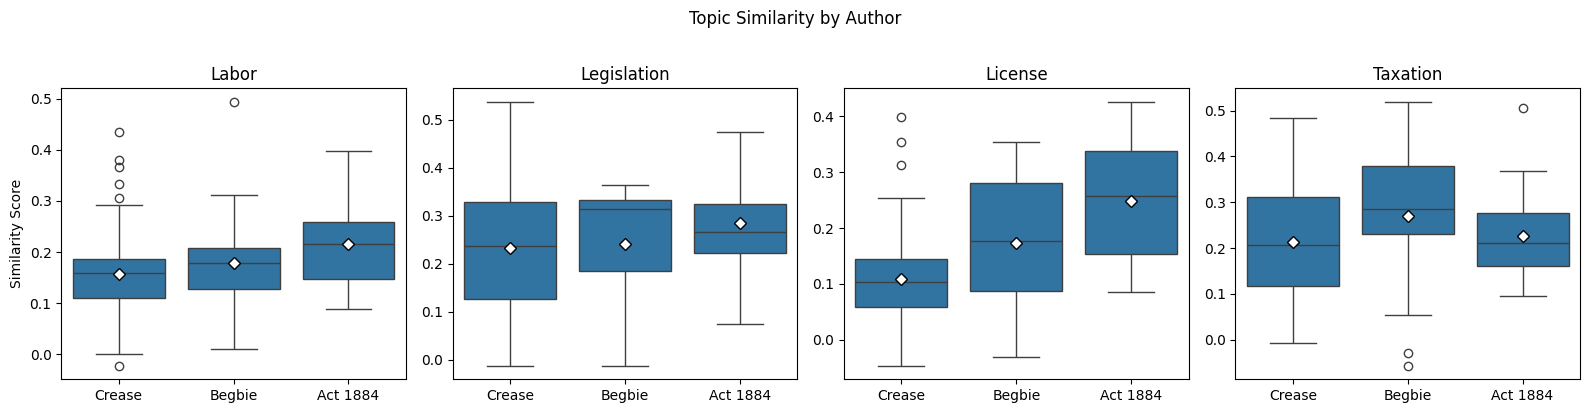

In [14]:
# Topic alignment box plots
topics = ['labor', 'legislation', 'license', 'taxation']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, topic in enumerate(topics):
    sub = similarity_df[
        similarity_df['Topic'] == topic
    ]
    sns.boxplot(
        data=sub, x='Author',
        y='Similarity Score', ax=axes[i],
        order=['Crease', 'Begbie', 'Act 1884'],
        showmeans=True,
        meanprops={
            'marker': 'D', 'markerfacecolor': 'white',
            'markeredgecolor': 'black',
        },
    )
    axes[i].set_title(topic.title())
    axes[i].set_xlabel('')
    if i > 0:
        axes[i].set_ylabel('')
plt.suptitle(
    'Topic Similarity by Author', y=1.02
)
plt.tight_layout()
plt.savefig(
    os.path.join(
        DATA_DIR,
        'natural-language-inference-'
        'historical-text-02.png',
    ),
    dpi=150, bbox_inches='tight',
)
plt.show()

## 9. Zero-Shot NLI Classification

### Label Design

In [15]:
# Primary labels
zs_labels = [
    (
        'advocates for equal legal treatment'
        ' of Chinese immigrants compared to'
        ' white or European settlers,'
        ' opposing racial discrimination'
    ),
    (
        'describes or retells the status or'
        ' treatment of Chinese immigrants'
        ' without expressing support or'
        ' opposition to racial inequality,'
        ' is unrelated to Chinese immigrants,'
        ' or cannot be classified as either'
    ),
    (
        'justifies or reinforces unequal'
        ' legal treatment of Chinese'
        ' immigrants relative to white or'
        ' European settlers, supporting'
        ' racially discriminatory policies'
    ),
]
label_short = ['Pro', 'Neutral', 'Cons']

HYPOTHESIS_TEMPLATE = (
    'In this snippet of a historical'
    ' legal text, the author {}.'
)

def get_scores(snippet, labels=None):
    if labels is None:
        labels = zs_labels
    if not snippet or len(snippet.strip()) < 10:
        return {l: 1/len(labels) for l in labels}
    out = zero_shot(
        snippet,
        candidate_labels=labels,
        hypothesis_template=HYPOTHESIS_TEMPLATE,
    )
    return dict(zip(out['labels'], out['scores']))

### Validation with Known Example

In [16]:
chapleau_snippet = (
    'That assuming Chinese immigrants of the'
    ' laboring class will persist in retaining'
    ' their present characteristics of Asiatic'
    ' life, where these are strikingly peculiar'
    ' and distinct from western, and that the'
    ' influx will continue to increase, this'
    ' immigration should be dealt with by'
    ' Parliament; but no legislation should be'
    ' such as would give a shock to great'
    ' interests and enterprises established'
    ' before any probability that Parliament'
    ' would interfere with that immigration'
    ' arose.'
)

scores = get_scores(chapleau_snippet)
print('Scores for Chapleau snippet:')
for label, score in scores.items():
    short = label_short[
        zs_labels.index(label)
    ]
    print(f'  {short}: {score:.4f}')

Scores for Chapleau snippet:
  Neutral: 0.5767
  Cons: 0.4105
  Pro: 0.0128


### Evaluate on Labelled Ground Truth

We have 44 manually annotated sentences in `labelled_snippets.csv` that serve as ground truth for evaluating the NLI model.

In [17]:
# Load ground truth
gt_df = pd.read_csv(
    os.path.join(DATA_DIR, 'labelled_snippets.csv')
)
print(f'Ground truth: {len(gt_df)} samples')
print(gt_df['Label'].value_counts())

# Map NLI labels to ground truth format
label_map = {
    zs_labels[0]: 'entailment',
    zs_labels[1]: 'neutral',
    zs_labels[2]: 'contradiction',
}

gt_preds = []
for _, row in gt_df.iterrows():
    scores = get_scores(row['Sentence'])
    pred_label = max(scores, key=scores.get)
    pred_short = label_map[pred_label]
    gt_preds.append({
        'sentence': row['Sentence'][:60],
        'true': row['Label'],
        'pred': pred_short,
        'correct': pred_short == row['Label'],
        'pro_score': scores[zs_labels[0]],
        'neutral_score': scores[zs_labels[1]],
        'cons_score': scores[zs_labels[2]],
    })

gt_results = pd.DataFrame(gt_preds)
accuracy = gt_results['correct'].mean()
print(f'\nAccuracy on ground truth: {accuracy:.3f}')
print(f'({gt_results["correct"].sum()}/'
      f'{len(gt_results)} correct)')

# Confusion matrix
from sklearn.metrics import (
    classification_report, confusion_matrix,
)
print('\nClassification report:')
print(classification_report(
    gt_results['true'], gt_results['pred'],
))

Ground truth: 44 samples
Label
contradiction    23
neutral          18
entailment        3
Name: count, dtype: int64

Accuracy on ground truth: 0.727
(32/44 correct)

Classification report:
               precision    recall  f1-score   support

contradiction       0.72      0.78      0.75        23
   entailment       1.00      1.00      1.00         3
      neutral       0.69      0.61      0.65        18

     accuracy                           0.73        44
    macro avg       0.80      0.80      0.80        44
 weighted avg       0.73      0.73      0.72        44



### Sentence-Level Classification

In [18]:
# Classify all extracted snippets
all_sentence_scores = []
for auth, snippets in act_snippets.items():
    print(f'Classifying {auth} '
          f'({len(snippets)} sentences)...')
    for snippet in snippets:
        scores = get_scores(snippet)
        all_sentence_scores.append({
            'Author': auth,
            'Text': snippet,
            'Pro': scores[zs_labels[0]],
            'Neutral': scores[zs_labels[1]],
            'Cons': scores[zs_labels[2]],
        })

df_scores = pd.DataFrame(all_sentence_scores)
df_scores.to_csv(
    os.path.join(
        DATA_DIR, 'zero_shot_sentence_scores.csv'
    ),
    index=False,
)
print('\nSaved zero_shot_sentence_scores.csv')

# Mean scores by author
mean_scores = (
    df_scores
    .groupby('Author')[['Pro', 'Neutral', 'Cons']]
    .mean()
)
print('\nMean scores by author (sentence):')
print(mean_scores.round(4))

Classifying Crease (83 sentences)...
Classifying Begbie (18 sentences)...
Classifying Act 1884 (24 sentences)...

Saved zero_shot_sentence_scores.csv

Mean scores by author (sentence):
             Pro  Neutral    Cons
Author                           
Act 1884  0.0248   0.3773  0.5979
Begbie    0.2719   0.1350  0.5931
Crease    0.1249   0.4936  0.3815


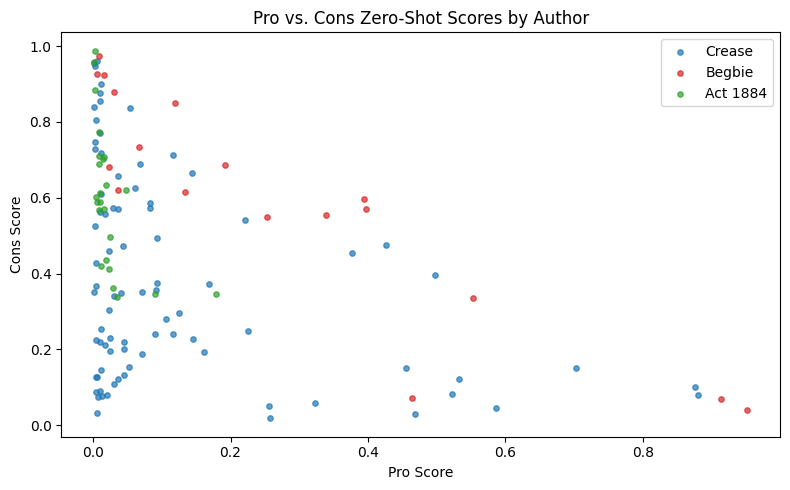

In [19]:
# Pro vs Cons scatter
fig, ax = plt.subplots(figsize=(8, 5))
for author, color in color_map.items():
    sub = df_scores[df_scores['Author'] == author]
    ax.scatter(
        sub['Pro'], sub['Cons'],
        c=color, label=author, s=15, alpha=0.7,
    )
ax.set_xlabel('Pro Score')
ax.set_ylabel('Cons Score')
ax.set_title(
    'Pro vs. Cons Zero-Shot Scores by Author'
)
ax.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(
        DATA_DIR,
        'natural-language-inference-'
        'historical-text-03.png',
    ),
    dpi=150,
)
plt.show()

### Window-Level Classification

In [20]:
from transformers import AutoTokenizer

nli_tokenizer = AutoTokenizer.from_pretrained(
    nli_model_name
)

def chunk_into_windows(
    text, max_tokens=512, stride=128
):
    sents = sent_tokenize(text)
    windows, current = [], ''
    for sent in sents:
        cand = (
            current + ' ' + sent
            if current else sent
        )
        n = len(nli_tokenizer.encode(
            cand, add_special_tokens=False
        ))
        if n <= max_tokens:
            current = cand
        else:
            windows.append(current)
            tail = nli_tokenizer.encode(
                current,
                add_special_tokens=False,
            )[-stride:]
            current = (
                nli_tokenizer.decode(tail)
                + ' ' + sent
            )
    if current:
        windows.append(current)
    return windows

# Classify windows for each author
all_window_scores = []
for auth, texts in act_dict.items():
    full_text = ' '.join(texts)
    windows = chunk_into_windows(full_text)
    print(f'{auth}: {len(windows)} windows')
    for w in windows:
        scores = get_scores(w)
        all_window_scores.append({
            'Author': auth,
            'Text': w[:200],
            'Pro': scores[zs_labels[0]],
            'Neutral': scores[zs_labels[1]],
            'Cons': scores[zs_labels[2]],
        })

all_scores_w = pd.DataFrame(all_window_scores)
all_scores_w.to_csv(
    os.path.join(
        DATA_DIR, 'zero_shot_windowed_scores.csv'
    ),
    index=False,
)
print('\nSaved zero_shot_windowed_scores.csv')

mean_w = (
    all_scores_w
    .groupby('Author')[['Pro', 'Neutral', 'Cons']]
    .mean()
)
print('\nMean scores by author (window):')
print(mean_w.round(4))

Token indices sequence length is longer than the specified maximum sequence length for this model (582 > 512). Running this sequence through the model will result in indexing errors


Crease: 30 windows
Begbie: 19 windows
Act 1884: 8 windows

Saved zero_shot_windowed_scores.csv

Mean scores by author (window):
             Pro  Neutral    Cons
Author                           
Act 1884  0.0441   0.2899  0.6660
Begbie    0.3767   0.2977  0.3255
Crease    0.3150   0.3341  0.3509


## 10. Robustness Checks

### 10a. Quote Sensitivity Analysis

Compare zero-shot results with and without high-similarity (quoted) sentences.

In [21]:
# Tag Crease snippets with quote similarity
crease_scores = df_scores[
    df_scores['Author'] == 'Crease'
].copy()
crease_scores['quote_sim'] = [
    compute_quote_similarity(t, act_sents)
    for t in crease_scores['Text']
]

for threshold in [0.3, 0.4, 0.5, 0.6]:
    filtered = crease_scores[
        crease_scores['quote_sim'] <= threshold
    ]
    n_removed = len(crease_scores) - len(filtered)
    means = filtered[['Pro', 'Neutral', 'Cons']].mean()
    print(
        f'Threshold {threshold:.1f}: '
        f'{n_removed} removed, '
        f'Pro={means["Pro"]:.4f} '
        f'Neutral={means["Neutral"]:.4f} '
        f'Cons={means["Cons"]:.4f}'
    )

# Full (no filtering)
full_means = crease_scores[
    ['Pro', 'Neutral', 'Cons']
].mean()
print(
    f'No filter:       '
    f'Pro={full_means["Pro"]:.4f} '
    f'Neutral={full_means["Neutral"]:.4f} '
    f'Cons={full_means["Cons"]:.4f}'
)

Threshold 0.3: 59 removed, Pro=0.1126 Neutral=0.3957 Cons=0.4917
Threshold 0.4: 8 removed, Pro=0.1270 Neutral=0.5009 Cons=0.3722
Threshold 0.5: 0 removed, Pro=0.1249 Neutral=0.4936 Cons=0.3815
Threshold 0.6: 0 removed, Pro=0.1249 Neutral=0.4936 Cons=0.3815
No filter:       Pro=0.1249 Neutral=0.4936 Cons=0.3815


### 10b. Label Sensitivity Analysis

Test two alternative label phrasings to check that results are robust to label wording.

In [22]:
# Alternative label set 1: shorter phrasing
alt_labels_1 = [
    'supports equal rights for Chinese immigrants',
    (
        'is neutral or unrelated to Chinese'
        ' immigrant rights'
    ),
    (
        'supports discriminatory treatment of'
        ' Chinese immigrants'
    ),
]

# Alternative label set 2: legal framing
alt_labels_2 = [
    (
        'argues that Chinese immigrants'
        ' deserve the same legal protections'
        ' as other residents'
    ),
    (
        'discusses Chinese immigration'
        ' without taking a clear legal'
        ' position for or against'
    ),
    (
        'argues that restricting Chinese'
        ' immigrants through law is'
        ' justified or necessary'
    ),
]

# Test on a sample of 20 sentences per author
sample_scores = df_scores.groupby('Author').head(20)

for label_name, labels in [
    ('Primary', zs_labels),
    ('Alt-short', alt_labels_1),
    ('Alt-legal', alt_labels_2),
]:
    results = []
    for _, row in sample_scores.iterrows():
        s = get_scores(row['Text'], labels)
        results.append({
            'Author': row['Author'],
            'Pro': s[labels[0]],
            'Neutral': s[labels[1]],
            'Cons': s[labels[2]],
        })
    rdf = pd.DataFrame(results)
    means = rdf.groupby('Author')[
        ['Pro', 'Neutral', 'Cons']
    ].mean()
    print(f'\n--- {label_name} ---')
    print(means.round(4))


--- Primary ---
             Pro  Neutral    Cons
Author                           
Act 1884  0.0146   0.3441  0.6413
Begbie    0.2719   0.1350  0.5931
Crease    0.1281   0.5214  0.3505

--- Alt-short ---
             Pro  Neutral    Cons
Author                           
Act 1884  0.0139   0.6578  0.3283
Begbie    0.4075   0.3548  0.2378
Crease    0.1807   0.7033  0.1160

--- Alt-legal ---
             Pro  Neutral    Cons
Author                           
Act 1884  0.0590   0.3801  0.5609
Begbie    0.4856   0.1638  0.3505
Crease    0.2903   0.4581  0.2516


### 10c. Bootstrap Confidence Intervals

In [23]:
def bootstrap_ci(
    data, n_boot=1000, ci=0.95, seed=42
):
    rng = np.random.default_rng(seed)
    means = []
    for _ in range(n_boot):
        sample = rng.choice(
            data, size=len(data), replace=True
        )
        means.append(np.mean(sample))
    lo = np.percentile(means, (1 - ci) / 2 * 100)
    hi = np.percentile(means, (1 + ci) / 2 * 100)
    return np.mean(data), lo, hi

print('Bootstrap 95% CIs on mean scores:\n')
for author in ['Crease', 'Begbie', 'Act 1884']:
    sub = df_scores[
        df_scores['Author'] == author
    ]
    print(f'--- {author} (n={len(sub)}) ---')
    for stance in ['Pro', 'Neutral', 'Cons']:
        m, lo, hi = bootstrap_ci(
            sub[stance].values
        )
        print(
            f'  {stance}: {m:.4f} '
            f'[{lo:.4f}, {hi:.4f}]'
        )
    print()

Bootstrap 95% CIs on mean scores:

--- Crease (n=83) ---
  Pro: 0.1249 [0.0852, 0.1716]
  Neutral: 0.4936 [0.4367, 0.5523]
  Cons: 0.3815 [0.3260, 0.4363]

--- Begbie (n=18) ---
  Pro: 0.2719 [0.1468, 0.4136]
  Neutral: 0.1350 [0.0771, 0.2009]
  Cons: 0.5931 [0.4474, 0.7190]

--- Act 1884 (n=24) ---
  Pro: 0.0248 [0.0127, 0.0423]
  Neutral: 0.3773 [0.3083, 0.4409]
  Cons: 0.5979 [0.5271, 0.6724]



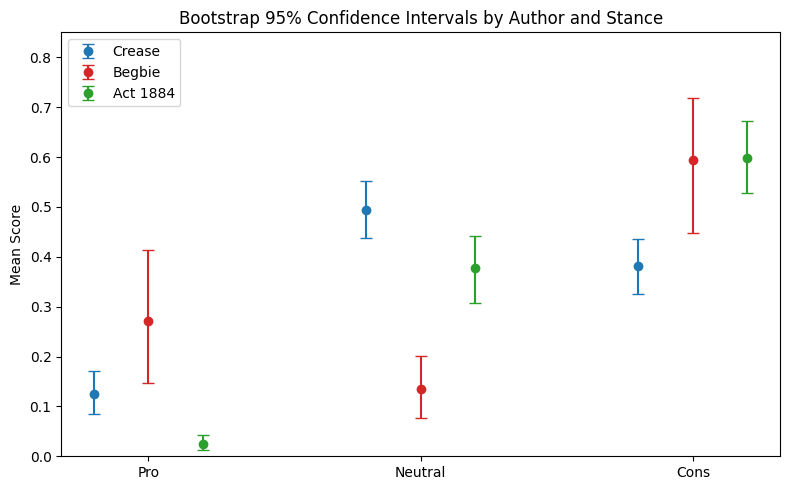

Saved bootstrap_ci.csv and figure 04.


In [28]:
# Build CI data for plotting
ci_rows = []
for author in ['Crease', 'Begbie', 'Act 1884']:
    sub = df_scores[
        df_scores['Author'] == author
    ]
    for stance in ['Pro', 'Neutral', 'Cons']:
        m, lo, hi = bootstrap_ci(
            sub[stance].values
        )
        ci_rows.append({
            'Author': author,
            'Stance': stance,
            'Mean': m,
            'CI_lo': lo,
            'CI_hi': hi,
        })

ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv(
    os.path.join(DATA_DIR, 'bootstrap_ci.csv'),
    index=False,
)

# Plot bootstrap CIs
fig, ax = plt.subplots(figsize=(8, 5))
stance_order = ['Pro', 'Neutral', 'Cons']
authors = ['Crease', 'Begbie', 'Act 1884']
offsets = {
    'Crease': -0.2, 'Begbie': 0.0,
    'Act 1884': 0.2,
}
colors = {
    'Crease': '#1f77b4',
    'Begbie': '#d62728',
    'Act 1884': '#2ca02c',
}

for author in authors:
    sub = ci_df[ci_df['Author'] == author]
    x = [
        stance_order.index(s) + offsets[author]
        for s in sub['Stance']
    ]
    ax.errorbar(
        x, sub['Mean'],
        yerr=[
            sub['Mean'] - sub['CI_lo'],
            sub['CI_hi'] - sub['Mean'],
        ],
        fmt='o', color=colors[author],
        label=author, capsize=4,
        markersize=6, linewidth=1.5,
    )

ax.set_xticks(range(len(stance_order)))
ax.set_xticklabels(stance_order)
ax.set_ylabel('Mean Score')
ax.set_title(
    'Bootstrap 95% Confidence Intervals'
    ' by Author and Stance'
)
ax.legend()
ax.set_ylim(0, 0.85)
plt.tight_layout()
plt.savefig(
    os.path.join(
        DATA_DIR,
        'natural-language-inference-'
        'historical-text-04.png',
    ),
    dpi=150,
)
plt.show()
print('Saved bootstrap_ci.csv and figure 04.')

### 10d. Full Corpus Baseline

Use commission reports as a background baseline to check whether the judges' scores differ from the corpus average.

In [24]:
# Extract snippets from all report texts
report_texts = df[
    df['type'] == 'report'
]['text'].tolist()

report_snippets = []
for txt in report_texts:
    sents = [s.text for s in nlp(txt).sents]
    for s in sents:
        if any(kw in s for kw in keywords):
            report_snippets.append(s)

print(f'Report snippets: {len(report_snippets)}')

# Classify a random sample (max 50)
rng = np.random.default_rng(42)
if len(report_snippets) > 50:
    sample_idx = rng.choice(
        len(report_snippets), 50, replace=False
    )
    sample_report = [
        report_snippets[i] for i in sample_idx
    ]
else:
    sample_report = report_snippets

report_scores = []
print('Classifying report snippets...')
for snippet in sample_report:
    scores = get_scores(snippet)
    report_scores.append({
        'Pro': scores[zs_labels[0]],
        'Neutral': scores[zs_labels[1]],
        'Cons': scores[zs_labels[2]],
    })

report_df = pd.DataFrame(report_scores)
print('\nCorpus baseline (commission reports):')
print(report_df.mean().round(4))
print('\nComparison with case authors:')
print(mean_scores.round(4))

Report snippets: 180
Classifying report snippets...

Corpus baseline (commission reports):
Pro        0.0618
Neutral    0.3605
Cons       0.5777
dtype: float64

Comparison with case authors:
             Pro  Neutral    Cons
Author                           
Act 1884  0.0248   0.3773  0.5979
Begbie    0.2719   0.1350  0.5931
Crease    0.1249   0.4936  0.3815


## 11. Putting It All Together: Topic-Stance Correlation

In [25]:
def clean_text(text):
    text = text.lower()
    return re.sub(r'[^\w\s]', '', text).strip()

similarity_wide = similarity_df.pivot(
    index=['Author', 'Text'],
    columns='Topic',
    values='Similarity Score',
).reset_index()
similarity_wide['key'] = (
    similarity_wide['Text'].apply(clean_text)
)

df_scores['key'] = (
    df_scores['Text'].apply(clean_text)
)

merged_df = similarity_wide.merge(
    df_scores[['key', 'Pro', 'Neutral', 'Cons']],
    on='key', how='inner',
)
print(f'Merged corpus: {len(merged_df)} sentences')

topics = ['labor', 'legislation',
          'license', 'taxation']
results = []
for author in merged_df['Author'].unique():
    sub = merged_df[
        merged_df['Author'] == author
    ]
    for topic in topics:
        for stance in ['Pro', 'Cons']:
            corr = (
                sub[[topic, stance]]
                .corr().iloc[0, 1]
            )
            results.append({
                'Author': author,
                'Topic': topic,
                'Stance': stance,
                'Correlation': round(corr, 4),
            })

corr_df = pd.DataFrame(results)
corr_wide = corr_df.pivot_table(
    index='Author',
    columns=['Topic', 'Stance'],
    values='Correlation',
)
print('\nCorrelation: topic alignment'
      ' vs stance by author:')
print(corr_wide)

Merged corpus: 125 sentences

Correlation: topic alignment vs stance by author:
Topic      labor         legislation         license         taxation        
Stance      Cons     Pro        Cons     Pro    Cons     Pro     Cons     Pro
Author                                                                       
Act 1884  0.0809 -0.3180     -0.0007  0.0686  0.1445 -0.3291   0.2497 -0.3016
Begbie    0.1115 -0.1393     -0.4066  0.3265 -0.1341 -0.0511   0.0448  0.0126
Crease    0.3094 -0.0839     -0.0197  0.1297  0.1053  0.0020   0.0255 -0.0634


## 12. Summary and Top Sentences

In [26]:
# Top Pro sentences
print('Top 5 Pro sentences:\n')
top_pro = df_scores.nlargest(5, 'Pro')
for _, row in top_pro.iterrows():
    txt = textwrap.fill(row['Text'], width=78)
    print(
        f'Author: {row["Author"]}\n'
        f'Text: {txt}\n'
        f'Pro: {row["Pro"]:.4f}\n'
    )

# Top Cons sentences
print('\nTop 5 Cons sentences:\n')
top_cons = df_scores.nlargest(5, 'Cons')
for _, row in top_cons.iterrows():
    txt = textwrap.fill(row['Text'], width=78)
    print(
        f'Author: {row["Author"]}\n'
        f'Text: {txt}\n'
        f'Cons: {row["Cons"]:.4f}\n'
    )

Top 5 Pro sentences:

Author: Begbie
Text: If the object of the Provincial Statute be as alleged, viz., Feb. 3.  to
subject Chinamen to exceptional disadvantages it is clearly unconstitutional.
Pro: 0.9523

Author: Begbie
Text: Rep. 354; Baker v. Portland, 5 Law 750; Teburcio Parrott's case, coram SAWYER
and HOFFMAN, J.J., 1880, and the Quene ordinance case, coram FIELD and SAWYER,
J.J., 1879; the two latter cases published in a separate pamphlet form, in
which the opinions of Mr. Justices FIELD, HOFFMAN, SAWYER and DEADY and other
Judges whom they cite, all confirm this, that a State, or Provincial law
imposing special disabilities or unequal burdens on Chinamen is
unconstitutional and void.
Pro: 0.9136

Author: Crease
Text: Opponents to the Act might as well contend the exclusion of the Chinese from
the franchise, and barring them from acquiring lands, was illegal.
Pro: 0.8810

Author: Crease
Text: In other words, every Chinese is guilty until proved innocent—a provision
which fills 

In [27]:
# Final summary table
print('=== FINAL SUMMARY ===\n')
print('Sentence-level mean scores:')
print(mean_scores.round(4))
print('\nWindow-level mean scores:')
print(mean_w.round(4))
print('\nGround truth accuracy:',
      f'{accuracy:.3f}')

=== FINAL SUMMARY ===

Sentence-level mean scores:
             Pro  Neutral    Cons
Author                           
Act 1884  0.0248   0.3773  0.5979
Begbie    0.2719   0.1350  0.5931
Crease    0.1249   0.4936  0.3815

Window-level mean scores:
             Pro  Neutral    Cons
Author                           
Act 1884  0.0441   0.2899  0.6660
Begbie    0.3767   0.2977  0.3255
Crease    0.3150   0.3341  0.3509

Ground truth accuracy: 0.727


In [29]:
# Save ground truth evaluation results
gt_results.to_csv(
    os.path.join(DATA_DIR, 'ground_truth_eval.csv'),
    index=False,
)

# Save topic-stance correlations
corr_df.to_csv(
    os.path.join(DATA_DIR, 'topic_stance_corr.csv'),
    index=False,
)

# List all generated data files
print('Generated data files:\n')
for fname in sorted(os.listdir(DATA_DIR)):
    fpath = os.path.join(DATA_DIR, fname)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath)
        print(f'  {fname:50s} {size:>10,} bytes')

Generated data files:

  Chapleau_Report_clean.txt                             401,678 bytes
  Commission_Report _Whole_Book.txt                   2,039,129 bytes
  Regina_V_Wing_Chong.txt                                44,425 bytes
  begbie_commission.txt                                  41,272 bytes
  bootstrap_ci.csv                                          683 bytes
  case_snippet_embeddings.npz                           384,758 bytes
  case_snippet_embeddings.pkl                           388,458 bytes
  chapleau_report_resume.txt                             10,907 bytes
  chinese_regulation_act_1884.txt                        12,934 bytes
  cleaned_text_commission_report_pages_all.txt        2,039,131 bytes
  commission_on_chinese_imigration.txt                    3,402 bytes
  crease_commission.txt                                  30,771 bytes
  embedding_visualization.png                            43,209 bytes
  ground_truth_eval.csv                                   6,623 byt